In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PROCESSED= "../data/processed/"
RAW= "../data/raw/"

orders=pd.read_csv(PROCESSED+"orders_clean.csv", parse_dates=[
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
    ])

payments=pd.read_csv(PROCESSED+"payments_clean.csv")
products=pd.read_csv(PROCESSED+"products_clean.csv")
reviews = pd.read_csv(RAW + "olist_order_reviews_dataset.csv")


print("✓Orders:", orders.shape)
print("✓Payments:", payments.shape)
print("✓Products:", products.shape)
print("✓ Reviews:", reviews.shape)

✓Orders: (99441, 10)
✓Payments: (103881, 5)
✓Products: (32951, 9)
✓ Reviews: (99224, 7)


In [3]:
RAW = "../data/raw/"

customers = pd.read_csv(RAW + "olist_customers_dataset.csv")
order_items = pd.read_csv(RAW + "olist_order_items_dataset.csv")
categories = pd.read_csv(RAW + "product_category_name_translation.csv")

print("✓ Customers:", customers.shape)
print("✓ Order Items:", order_items.shape)
print("✓ Categories:", categories.shape)

✓ Customers: (99441, 5)
✓ Order Items: (112650, 7)
✓ Categories: (71, 2)


In [4]:
df=orders.merge(payments, on="order_id")
print(df.shape)

(103881, 14)


In [5]:
# Extract month from purchase date
df['month']=df['order_purchase_timestamp'].dt.to_period('M')
print(df['month'].head())

0    2017-10
1    2017-10
2    2017-10
3    2018-07
4    2018-08
Name: month, dtype: period[M]


In [6]:
monthly_revenue=df.groupby('month')['payment_value'].sum()
print(monthly_revenue.head(10))

month
2016-09       252.24
2016-10     59090.48
2016-12        19.62
2017-01    138488.04
2017-02    291908.01
2017-03    449863.60
2017-04    417788.03
2017-05    592918.82
2017-06    511276.38
2017-07    592382.92
Freq: M, Name: payment_value, dtype: float64


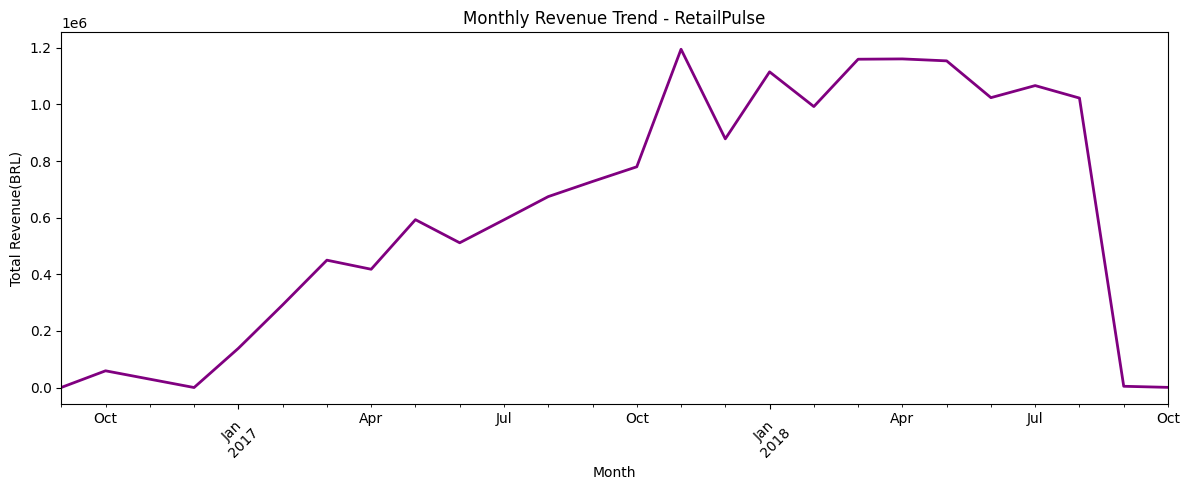

In [30]:
# Chart 1: Monthly Revenue Trend
plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind='line',color='purple',linewidth=2)
plt.title('Monthly Revenue Trend - RetailPulse')
plt.xlabel('Month')
plt.ylabel('Total Revenue(BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../Reports/monthly_revenue.png', dpi=150, bbox_inches='tight')  #
plt.show()

##Chart 1 - Monthly Revenue Trend

###  What I see:
- Revenue grew steadily from early 2017 onwards
-Strong growth from Jan 2017 to Nov 2017
-November 2017 spike-likely Black Friday effect
-Revenue plateaued around BRL 1M per month in 2018
Sharp drop at end - incomplete data for Oct 2018

### Business Insight:
Olist shows strong consistent growth throughout 2017.
The Black Friday spike suggests seasonal marketing opportunity —
Olist should plan inventory and logistics specifically for November.
The 2018 plateau suggests growth is slowing and needs investigation.




In [8]:
revenue_by_category= (
    order_items
    .merge(payments, on='order_id')
    .merge(products, on='product_id')
    .merge(categories, on='product_category_name')
    .groupby('product_category_name_english')['payment_value'].sum()
    .nlargest(10)
    .sort_values()
)

print(revenue_by_category)

product_category_name_english
cool_stuff                779698.00
garden_tools              838280.75
auto                      852294.33
housewares               1094498.25
sports_leisure           1392127.56
watches_gifts            1429216.68
furniture_decor          1430176.39
computers_accessories    1585330.45
health_beauty            1657373.12
bed_bath_table           1712553.67
Name: payment_value, dtype: float64


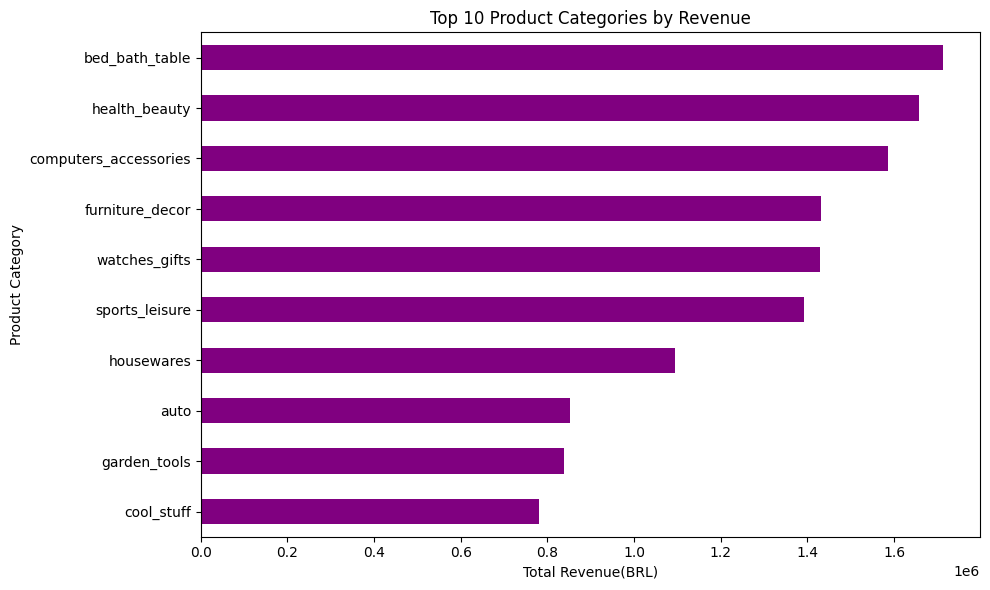

In [29]:
plt.figure(figsize=(10, 6))
revenue_by_category.plot(kind='barh',color='purple')
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Total Revenue(BRL)')
plt.ylabel('Product Category')
plt.tight_layout()
plt.savefig('../Reports/monthly_revenue.png', dpi=150, bbox_inches='tight')  #
plt.show()

## Chart 2 — Top 10 Categories by Revenue

### What I see:
- bed_bath_table is #1 at BRL 1.7M
- health_beauty is #2 at BRL 1.6M
- furniture_decor and watches_gifts are nearly equal at BRL 1.4M
- cool_stuff is lowest in top 10 at BRL 0.78M

### Business Insight:
Olist's revenue is driven by everyday household essentials,
not luxury or high-tech products. This suggests the core
customer is a practical middle-income buyer. Marketing and
inventory investment should prioritize bed/bath, health,
and computer accessories categories.

### Watch out:
health_beauty is #2 in revenue but had the highest
data quality issues in cleaning — return rate investigation
needed in advanced analytics phase.

In [10]:
reviews['review_score'].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

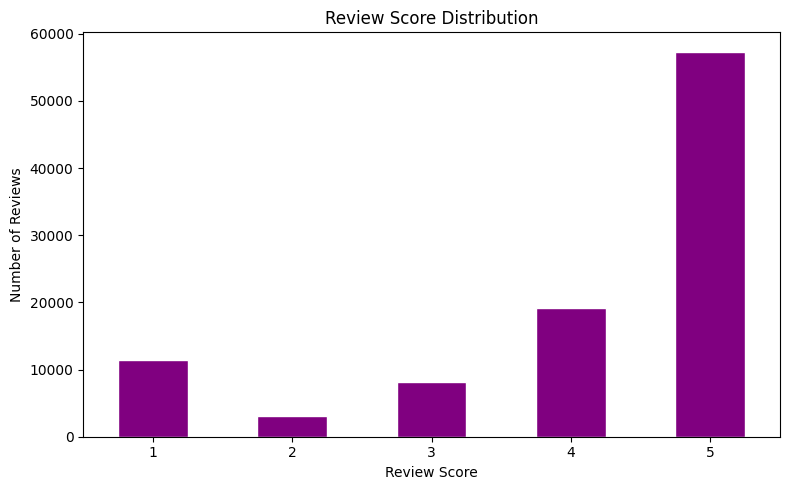

In [28]:
plt.figure(figsize=(8,5))
reviews['review_score'].value_counts().sort_index().plot(
    kind='bar',color='purple',edgecolor='white'
)
plt.title('Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../Reports/monthly_revenue.png', dpi=150, bbox_inches='tight')  #
plt.show()

## Chart 3 — Review Score Distribution

### What I see:
- 58% of customers gave 5 stars — majority are satisfied
- 11,424 customers gave 1 star — significant unhappy segment
- Very few 2 and 3 star reviews — classic J-curve pattern

### Business Insight:
1-star reviews are likely driven by long delivery times.
Average delivery is 12 days with a max of 188 days.
Olist should target reducing delivery to under 7 days
by improving seller shipping deadlines and logistics
partnerships — especially in underserved states.

### Connection:
Faster delivery → higher reviews → more repeat purchases
→ solves the low repeat rate identified earlier.

In [12]:
df2 = orders.merge(reviews, on='order_id')
print(df2.shape)

(99224, 16)


In [13]:
delivery_by_score=df2.groupby('review_score')['delivery_days'].mean().round(1)
print(delivery_by_score)

review_score
1    20.8
2    16.2
3    13.8
4    11.8
5    10.2
Name: delivery_days, dtype: float64


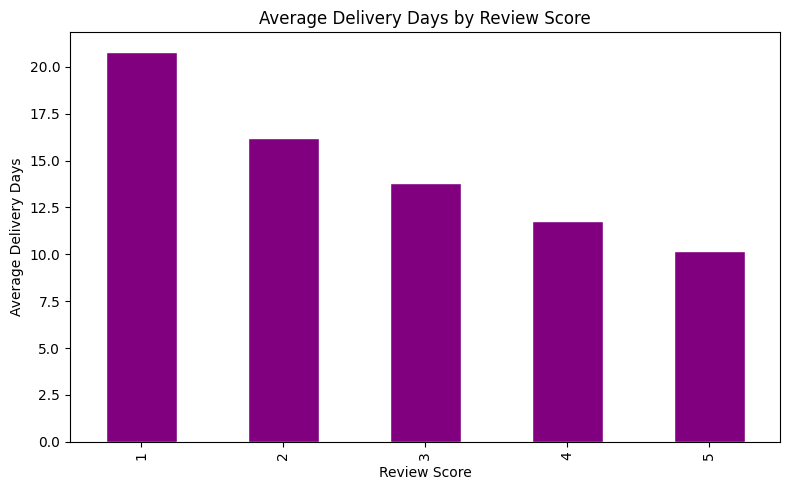

In [27]:
plt.figure(figsize=(8,5))
delivery_by_score.plot(kind='bar',color='purple',edgecolor='white')
plt.title('Average Delivery Days by Review Score')
plt.xlabel('Review Score')
plt.ylabel('Average Delivery Days')
plt.tight_layout()
plt.savefig('../Reports/monthly_revenue.png', dpi=150, bbox_inches='tight')  #
plt.show()

## Chart 4 — Delivery Time vs Review Score

### What I see:
- 1 star reviews → average 20.8 days delivery
- 5 star reviews → average 10.2 days delivery
- Perfect negative correlation — every star rating
  has lower delivery days than the one below it

### Business Insight:
Delivery time is the strongest driver of customer
satisfaction in this dataset. Customers who wait
20+ days are almost guaranteed to leave 1 star.
Customers who receive in 10 days give 5 stars.

### Recommendation:
Target delivery time under 10 days across all states.
Focus especially on underserved states where delivery
takes longest — this will simultaneously improve
reviews, repeat purchases, and geographic reach.

In [15]:
df3 = customers.merge(orders, on='customer_id')
df3=df3.merge(payments, on='order_id')
print(df3.shape)

(103881, 18)


In [16]:
revenue_by_state=df3.groupby('customer_state')["payment_value"].sum().sort_values(ascending=False)
print(revenue_by_state.head(10))

customer_state
SP    5998168.27
RJ    2144379.69
MG    1872257.26
RS     890898.54
PR     811156.38
SC     623086.43
BA     616515.88
DF     355141.08
GO     350092.31
ES     325967.55
Name: payment_value, dtype: float64


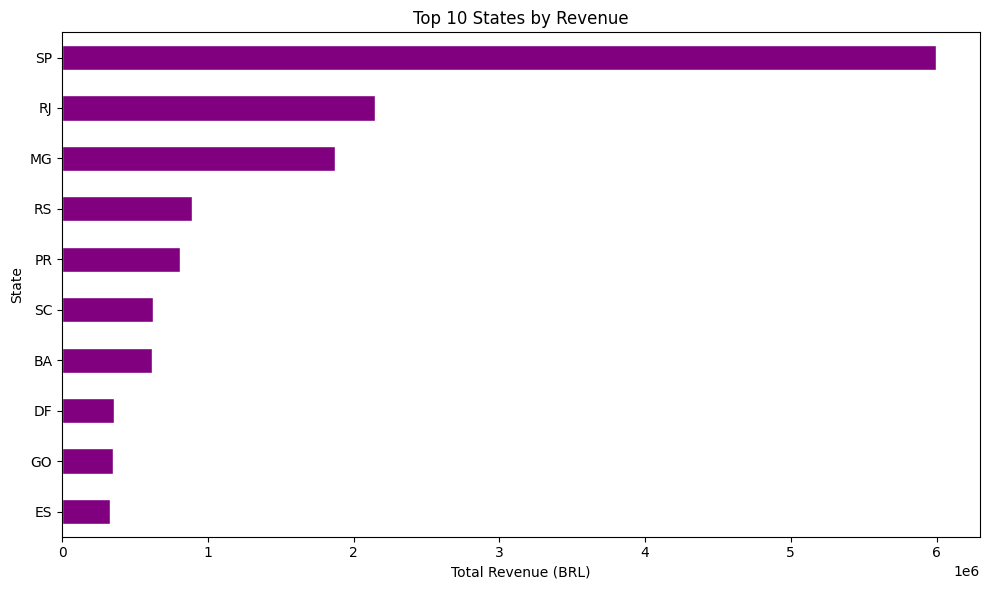

In [26]:
plt.figure(figsize=(10, 6))
revenue_by_state.head(10).sort_values().plot(
    kind='barh', color='purple', edgecolor='white'
)
plt.title('Top 10 States by Revenue')
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('../Reports/monthly_revenue.png', dpi=150, bbox_inches='tight')  #
plt.show()

In [24]:
category_revenue = (
    order_items
    .merge(payments, on='order_id')
    .merge(products, on='product_id')
    .merge(categories, on='product_category_name')
    .groupby('product_category_name_english')['payment_value']
    .sum()
    .nlargest(10)
    .reset_index()
)
category_revenue.columns = ['category', 'revenue']
category_revenue.to_csv('../data/processed/category_revenue.csv', index=False)
print(category_revenue)

                category     revenue
0         bed_bath_table  1712553.67
1          health_beauty  1657373.12
2  computers_accessories  1585330.45
3        furniture_decor  1430176.39
4          watches_gifts  1429216.68
5         sports_leisure  1392127.56
6             housewares  1094498.25
7                   auto   852294.33
8           garden_tools   838280.75
9             cool_stuff   779698.00


## Chart 5 — Revenue by State

### What I see:
- SP dominates at BRL 6M — nearly 3x bigger than RJ (BRL 2.1M)
- Top 3 states (SP, RJ, MG) contribute ~74% of total revenue
- Bottom 7 states in top 10 each contribute under BRL 1M
- 17+ states not even in top 10

### Business Insight:
Revenue concentration mirrors customer concentration.
SP has 42% of customers and 44% of revenue — meaning
customers spend similarly across all states.
This confirms geographic expansion is a direct
revenue opportunity — new customers = proportional
new revenue.

### Recommendation:
Target RJ and MG first for expansion — already
showing strong revenue signals. Then expand logistics
to RS and PR which show growth potential.

In [25]:
plt.savefig('../Reports/monthly_revenue.png', dpi=150, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>